In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet50

# Image Copying and Counting Function

In [2]:
base_dir = '/kaggle/working/dataset'

original_dirs = {
    'Calculus': '/kaggle/input/datasets/salmansajid05/oral-diseases/Calculus/Calculus',
    'Caries': '/kaggle/input/datasets/salmansajid05/oral-diseases/Data caries/Data caries',
    'Gingivitis': '/kaggle/input/datasets/salmansajid05/oral-diseases/Gingivitis/Gingivitis',
    'Ulcers': '/kaggle/input/datasets/salmansajid05/oral-diseases/Mouth Ulcer/Mouth Ulcer',
    'Tooth Discoloration': '/kaggle/input/datasets/salmansajid05/oral-diseases/Tooth Discoloration/Tooth Discoloration ',
    'Hypodontia': '/kaggle/input/datasets/salmansajid05/oral-diseases/hypodontia/hypodontia'
}

classes = list(original_dirs.keys())
class_split_counts = {cls: {} for cls in classes}

for class_name, src_dir in original_dirs.items():
    # Gather all images
    images = [
        os.path.join(root, f)
        for root, _, files in os.walk(src_dir)
        for f in files if f.endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Split: 72% train / 18% val / 10% test
    train, test   = train_test_split(images, test_size=0.1, random_state=42)
    train, val    = train_test_split(train,  test_size=0.2, random_state=42)

    # Copy to target directories
    for split, paths in zip(['train', 'val', 'test'], [train, val, test]):
        dest = os.path.join(base_dir, split, class_name)
        os.makedirs(dest, exist_ok=True)
        class_split_counts[class_name][split] = len(paths)
        for img in paths:
            shutil.copy(img, os.path.join(dest, os.path.basename(img)))

print("Images have been copied and organized successfully.")

Images have been copied and organized successfully.


In [3]:
class_split_counts

{'Calculus': {'train': 932, 'val': 234, 'test': 130},
 'Caries': {'train': 1872, 'val': 468, 'test': 261},
 'Gingivitis': {'train': 1684, 'val': 422, 'test': 234},
 'Ulcers': {'train': 2020, 'val': 505, 'test': 281},
 'Tooth Discoloration': {'train': 1452, 'val': 363, 'test': 202},
 'Hypodontia': {'train': 245, 'val': 62, 'test': 35}}

# Data Visualization

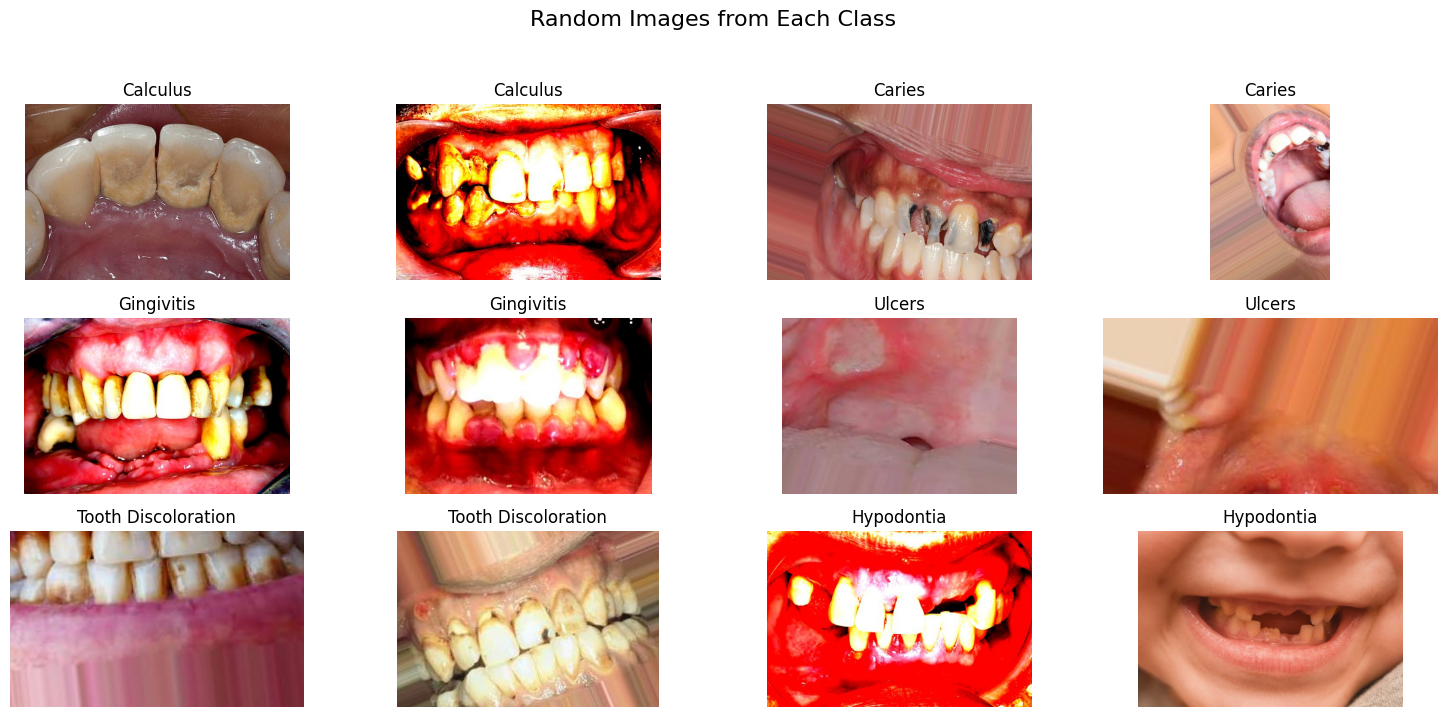

In [4]:
random.seed(42)
num_per_class, num_cols = 2, 4

# Collect image paths with their labels
samples = [
    (os.path.join(base_dir, 'train', cls, img), cls)
    for cls in classes
    for img in random.sample(os.listdir(os.path.join(base_dir, 'train', cls)), num_per_class)
]

# Plot images
fig, axs = plt.subplots(math.ceil(len(samples) / num_cols), num_cols, 
                        figsize=(15, math.ceil(len(samples) / num_cols) * 2.5))
fig.suptitle('Random Images from Each Class', fontsize=16)

for ax, (path, label) in zip(axs.flatten(), samples):
    ax.imshow(Image.open(path))
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

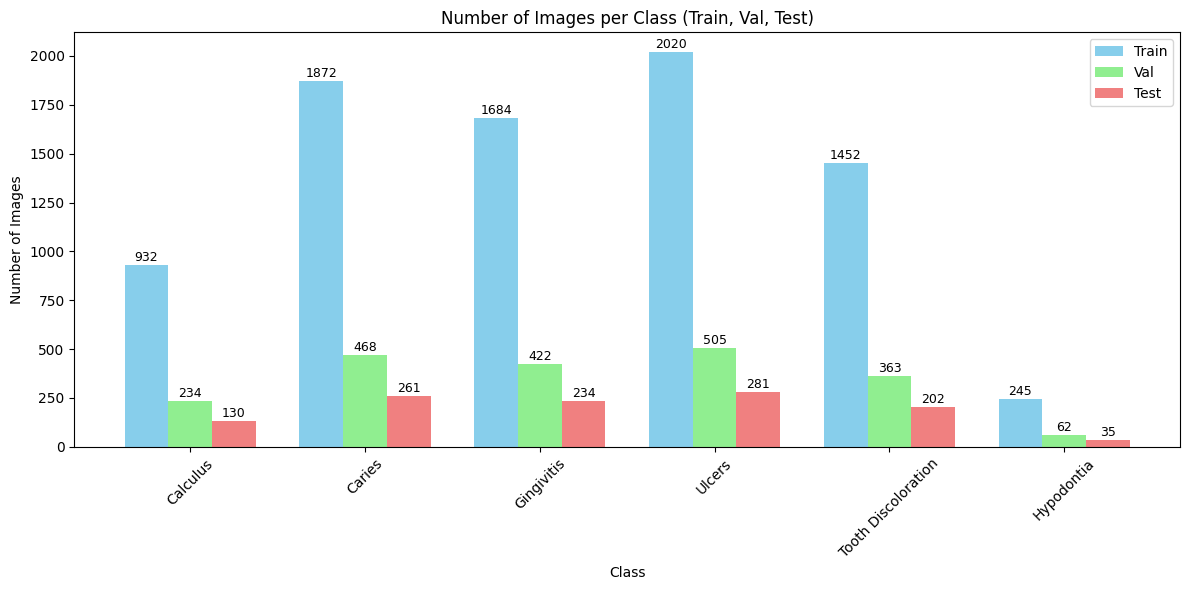

In [5]:
# Count images per class and split
class_split_counts = {
    cls: {split: len(os.listdir(os.path.join(base_dir, split, cls))) for split in ['train', 'val', 'test']}
    for cls in classes
}

# Prepare data
splits = ['train', 'val', 'test']
colors = ['skyblue', 'lightgreen', 'lightcoral']
width  = 0.25
x      = np.arange(len(classes))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, (split, color) in enumerate(zip(splits, colors)):
    counts = [class_split_counts[c][split] for c in classes]
    bars   = ax.bar(x + i * width, counts, width, label=split.capitalize(), color=color)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                int(b.get_height()), ha='center', va='bottom', fontsize=9)

ax.set(xlabel='Class', ylabel='Number of Images',
       title='Number of Images per Class (Train, Val, Test)',
       xticks=x + width, xticklabels=classes)
ax.set_xticklabels(classes, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Model Preparing and Training

In [ ]:
# Define directories
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')
# Parameters
image_size = (224, 224)
batch_size = 32
num_epochs = 50

# Data augmentation and normalization for training
train_transforms = transforms.Compose([
    # Slightly resize while preserving important details
    transforms.Resize(image_size),
    
    # Handle variations in shooting angles (handheld images)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    
    # Handle lighting variations in dental clinics (very important)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    
    transforms.ToTensor(),
    
    # Keep these values if using a pre-trained model like ResNet or EfficientNet
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Normalization for validation and testing
val_transforms = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_transforms)
test_dataset = ImageFolder(test_dir, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [11]:
# Get number of classes
num_classes = len(train_dataset.classes)

# Use ResNet18
class CustomModel(nn.Module):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.model = resnet50(weights=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Initialize the model, loss function, and optimizer
model = CustomModel()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Set environment variable to avoid threading issues
os.environ["OMP_NUM_THREADS"] = "1"

# Define the scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Early stopping parameters
early_stopping = True
patience = 5  # Number of epochs to wait if no improvement is observed

# Initialize early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop = False

# Initialize lists to store losses, accuracies, and learning rates
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Variables to store y_true and y_scores for precision-recall calculation
y_true = []
y_scores = []



In [13]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []
    val_outputs = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_true.extend(labels.cpu().numpy())
            val_outputs.extend(outputs.cpu().numpy())

    val_loss = val_loss / len(val_dataset)
    val_acc = accuracy_score(val_true, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Append true labels and predicted scores for precision-recall calculation
    y_true.extend(val_true)
    y_scores.extend(val_outputs)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Check for improvement in validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Save the model checkpoint here if you want

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping after {epoch+1} epochs.')
            early_stop = True
            break

    # LR scheduler step based on validation loss
    scheduler.step(val_loss)

    if early_stop:
        break

Epoch [1/50], Train Loss: 0.9246, Val Loss: 0.8455, Val Acc: 0.6811
Epoch [2/50], Train Loss: 0.6564, Val Loss: 0.6683, Val Acc: 0.7561
Epoch [3/50], Train Loss: 0.5346, Val Loss: 0.5007, Val Acc: 0.7955
Epoch [4/50], Train Loss: 0.5061, Val Loss: 0.4923, Val Acc: 0.8145
Epoch [5/50], Train Loss: 0.4427, Val Loss: 0.4534, Val Acc: 0.8145
Epoch [6/50], Train Loss: 0.4049, Val Loss: 0.3101, Val Acc: 0.8690
Epoch [7/50], Train Loss: 0.3515, Val Loss: 0.4382, Val Acc: 0.8267
Epoch [8/50], Train Loss: 0.3427, Val Loss: 0.2922, Val Acc: 0.8797
Epoch [9/50], Train Loss: 0.3252, Val Loss: 0.3450, Val Acc: 0.8539
Epoch [10/50], Train Loss: 0.2993, Val Loss: 0.3198, Val Acc: 0.8763
Epoch [11/50], Train Loss: 0.2918, Val Loss: 0.2902, Val Acc: 0.8783
Epoch [12/50], Train Loss: 0.2573, Val Loss: 0.3303, Val Acc: 0.8739
Epoch [13/50], Train Loss: 0.2767, Val Loss: 0.3308, Val Acc: 0.8612
Epoch [14/50], Train Loss: 0.2513, Val Loss: 0.3343, Val Acc: 0.8666
Epoch [15/50], Train Loss: 0.2430, Val Loss

# Model Evaluation

In [15]:
# Test the model
model.eval()
test_preds = []
test_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_preds.extend(predicted.cpu().numpy())
        test_true.extend(labels.cpu().numpy())

test_acc = accuracy_score(test_true, test_preds)
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9265


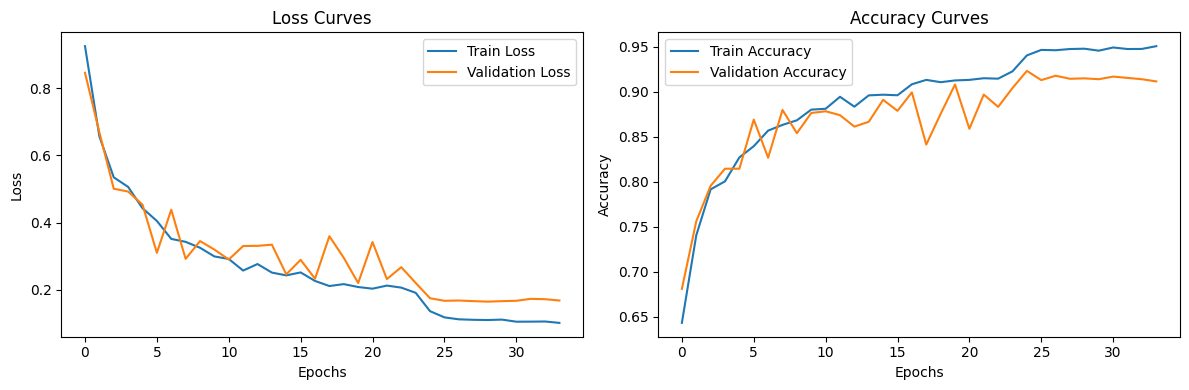

In [16]:
# Plotting loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plotting loss
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plotting accuracy
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()